In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [4]:
data_path = Path("data/merged_files/merged_v4.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")

In [5]:
data.head(3)

,region_id,time,alarm,hour_temp,hour_feelslike,hour_humidity,hour_dew,hour_precip,hour_precipprob,hour_preciptype,hour_windspeed,hour_winddir,hour_pressure,hour_visibility,hour_cloudcover,hour_uvindex,hour_conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,hour_of_day,day_of_week,is_weekend,text_length,cluster,news_count_7d,avg_dist_centroid_7d,topic_entropy_7d,dom_cluster_share_7d,news_velocity_7d,centroid_shift_7d,anomaly_count_7d,news_count_30d,avg_dist_centroid_30d,topic_entropy_30d,dom_cluster_share_30d,news_velocity_30d,centroid_shift_30d,anomaly_count_30d
0,2,2022-03-28 00:00:00+03:00,0,0.4,-2.2,43.82,-10.5,0.0,0.0,0,7.6,314.0,1029.0,24.1,2.0,0.0,0,13.0,5.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,86.0,289.0,-3.0,0.0,0.0,0.0,13953.0,9.0,7.0,0.345617,0.59827,0.714286,0.0,0.22995,1.0,29.0,0.396254,0.589003,0.724138,28.0,0.565055,3.0
1,2,2022-03-28 01:00:00+03:00,0,-0.1,-2.5,45.43,-10.5,0.0,0.0,0,6.8,308.6,1029.0,24.1,4.2,0.0,0,8.0,2.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,4.0,0.0,45.0,285.0,-3.0,1.0,0.0,0.0,13953.0,9.0,7.0,0.345617,0.59827,0.714286,0.0,0.22995,1.0,29.0,0.396254,0.589003,0.724138,28.0,0.565055,3.0
2,2,2022-03-28 02:00:00+03:00,0,-0.6,-2.3,47.87,-10.3,0.0,0.0,0,5.0,305.7,1029.0,24.1,3.1,0.0,0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,28.0,269.0,-2.0,2.0,0.0,0.0,13953.0,9.0,7.0,0.345617,0.59827,0.714286,0.0,0.22995,1.0,29.0,0.396254,0.589003,0.724138,28.0,0.565055,3.0


In [6]:
data.isna().sum().sum()

np.int64(0)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 759649 entries, 0 to 759648
Data columns (total 56 columns):
 #   Column                     Non-Null Count   Dtype                      
---  ------                     --------------   -----                      
 0   region_id                  759649 non-null  int64                      
 1   time                       759649 non-null  datetime64[us, Europe/Kyiv]
 2   alarm                      759649 non-null  int64                      
 3   hour_temp                  759649 non-null  float64                    
 4   hour_feelslike             759649 non-null  float64                    
 5   hour_humidity              759649 non-null  float64                    
 6   hour_dew                   759649 non-null  float64                    
 7   hour_precip                759649 non-null  float64                    
 8   hour_precipprob            759649 non-null  float64                    
 9   hour_preciptype            759649 non-null  int6

In [8]:
print(f"percent of alarms: {data['alarm'].sum() / len(data):.2%}")

percent of alarms: 20.51%


In [9]:
target = "alarm"

X = data.copy()
y = X.pop(target)

X["year"] = X["time"].dt.year.astype(int)
X["month"] = X["time"].dt.month.astype(int)
X["day"] = X["time"].dt.day.astype(int)

In [10]:
cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster"]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

print(f"Categorical columns:\n{cat_cols}")
print("-" * 20)
print(f"Numerical columns:\n{num_cols}")

Categorical columns:
['hour_preciptype', 'hour_conditions', 'is_weekend', 'cluster']
--------------------
Numerical columns:
['region_id', 'hour_temp', 'hour_feelslike', 'hour_humidity', 'hour_dew', 'hour_precip', 'hour_precipprob', 'hour_windspeed', 'hour_winddir', 'hour_pressure', 'hour_visibility', 'hour_cloudcover', 'hour_uvindex', 'messages_count', 'has_threat_sum', 'nlp_артобстрілу', 'nlp_бпла', 'nlp_відбій', 'nlp_відбій_тривоги', 'nlp_дніпропетровська', 'nlp_донецька', 'nlp_запорізька', 'nlp_нікополь', 'nlp_нікополь_нікопольська', 'nlp_нікопольська', 'nlp_повітряна', 'nlp_повітряна_тривога', 'nlp_тривога', 'nlp_тривоги', 'nlp_харківська', 'msg_count_last_3h', 'msg_count_last_24h', 'threat_diff_1h', 'hour_of_day', 'day_of_week', 'text_length', 'news_count_7d', 'avg_dist_centroid_7d', 'topic_entropy_7d', 'dom_cluster_share_7d', 'news_velocity_7d', 'centroid_shift_7d', 'anomaly_count_7d', 'news_count_30d', 'avg_dist_centroid_30d', 'topic_entropy_30d', 'dom_cluster_share_30d', 'news

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, matthews_corrcoef, f1_score
from time import time
import numpy as np

# define categorical and numerical columns
cat_cols = ["hour_preciptype", "hour_conditions", "is_weekend", "cluster"]
num_cols = [col for col in X.select_dtypes(include="number").columns if col not in cat_cols]

# create a preprocessor to scale only numerical columns
preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), num_cols)
], remainder='passthrough')

def train_model(model, X=X, y=y):
    # set up time series cross-validation
    tss = TimeSeriesSplit(n_splits=5, gap=24*7)
    unique_hours = X["time"].sort_values().unique()
    
    # dictionaries to store metrics for each fold
    auprc_scores = dict()
    mcc_scores = dict()
    f1_scores = dict()

    training_start = time()
    
    for fold, (train_idx, test_idx) in enumerate(tss.split(unique_hours)):
        fold_start = time()
        print(f"\n -Fold {fold + 1} / {tss.n_splits} started...")
        
        # get train and test hours for the current fold
        train_hours = unique_hours[train_idx]
        test_hours = unique_hours[test_idx]
    
        # split data and drop the time column
        X_train = X[X["time"].isin(train_hours)].drop(columns=["time"])
        y_train = y.loc[X_train.index]
        
        X_test = X[X["time"].isin(test_hours)].drop(columns=["time"])
        y_test = y.loc[X_test.index]

        # train the model
        model.fit(X_train, y_train)
        print("  Model trained", end=" | ")

        # make predictions and calculate probabilities
        y_prob = model.decision_function(X_test)
        y_pred = model.predict(X_test)
        
        # calculate metrics
        auprc_score = average_precision_score(y_test, y_prob)
        auprc_scores[f"Fold_{fold}"] = auprc_score

        mcc_score = matthews_corrcoef(y_test, y_pred)
        mcc_scores[f"Fold_{fold}"] = mcc_score
        
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f1_scores[f"Fold_{fold}"] = f1
        print(" Evaluated")

        # print results for the current fold
        print(f"  Metrics: AUPRC = {auprc_score:.4f} | MCC = {mcc_score:.4f} | F1 = {f1:.4f}")
        print(f"  Time: {time() - fold_start:.2f} sec")

    
    print("\n" + "="*45)
    print(" OVERALL CROSS-VALIDATION PERFORMANCE")
    print("="*45)
    print(f" AUPRC: {np.mean(list(auprc_scores.values())):.3f} (± {np.std(list(auprc_scores.values())):.3f})")
    print(f" MCC:   {np.mean(list(mcc_scores.values())):.3f} (± {np.std(list(mcc_scores.values())):.3f})")
    print(f" F1:    {np.mean(list(f1_scores.values())):.3f} (± {np.std(list(f1_scores.values())):.3f})")
    print(f" Total execution time: {time() - training_start:.2f} sec")
    print("="*45 + "\n")
    
    return auprc_scores, mcc_scores, f1_scores

In [14]:
print("Training Logistic Regression with parameter tuning (C_values)")

C_values = [0.01, 1.0, 10.0]

best_f1 = 0
best_C = None
best_auprc = 0
best_mcc = 0

for C_val in C_values:
    print(f"\n{'='*60}")
    print(f"   Testing Logistic Regression with C = {C_val}")
    print(f"{'='*60}\n")
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=C_val, max_iter=1500, class_weight='balanced'))
    ])
    
    auprc, mcc, f1 = train_model(pipeline)
    

    mean_f1 = np.mean(list(f1.values()))
    mean_auprc = np.mean(list(auprc.values()))
    mean_mcc = np.mean(list(mcc.values()))
    
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_C = C_val
        best_auprc = mean_auprc
        best_mcc = mean_mcc

print(f"\n{'*'*60}")
print(f"OVERALL BEST MODEL FOUND")
print(f"{'*'*60}")
print(f"Best hyperparameter C = {best_C}")
print(f"Average F1:    {best_f1:.3f}")
print(f"Average AUPRC: {best_auprc:.3f}")
print(f"Average MCC:   {best_mcc:.3f}")
print(f"{'*'*60}\n")

Training Logistic Regression with parameter tuning (C_values)

   Testing Logistic Regression with C = 0.01


➤ Fold 1 / 5 started...


KeyboardInterrupt: 

--- training final model with best c=0.01 for confusion matrix ---


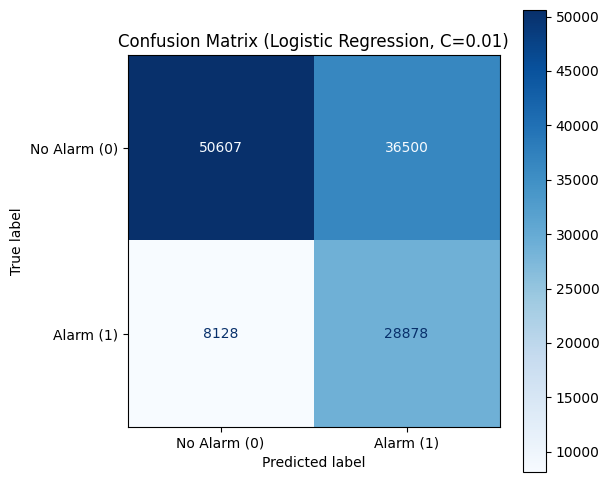

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import TimeSeriesSplit

print(f"--- training final model with best c={best_C} for confusion matrix ---")

tss = TimeSeriesSplit(n_splits=5, gap=24*7)
unique_hours = X["time"].sort_values().unique()

# taking the last fold for final evaluation
train_idx, test_idx = list(tss.split(unique_hours))[-1]
train_hours = unique_hours[train_idx]
test_hours = unique_hours[test_idx]

X_train = X[X["time"].isin(train_hours)].drop(columns=["time"])
y_train = y.loc[X_train.index]
X_test = X[X["time"].isin(test_hours)].drop(columns=["time"])
y_test = y.loc[X_test.index]

# final pipeline setup
best_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(transformers=[('scale', StandardScaler(), num_cols)], remainder='passthrough')),
    ("model", LogisticRegression(C=best_C, max_iter=1500, class_weight='balanced'))
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Alarm (0)", "Alarm (1)"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title(f"Confusion Matrix (Logistic Regression, C={best_C})")
plt.show()

### Confusion Matrix Metrics Explanation

The confusion matrix shows exactly how our model classifies the data and where it makes errors:
* **True Negative (TN, top-left):** The model predicted no alarm, and there was indeed no alarm. Correct prediction.
* **True Positive (TP, bottom-right):** The model predicted an alarm, and the alarm actually happened. Correct prediction.
* **False Positive (FP, top-right - Type I error):** The model raised a "false alarm" (predicted an alarm, but there was none). Since we used `class_weight='balanced'`, the model tends to be overly cautious, meaning it prefers to trigger a false alarm rather than miss a real one. This is why this number might be relatively high.
* **False Negative (FN, bottom-left - Type II error):** The most dangerous error in this context. The model predicted no alarm, but an air raid alarm actually occurred (a missed event).

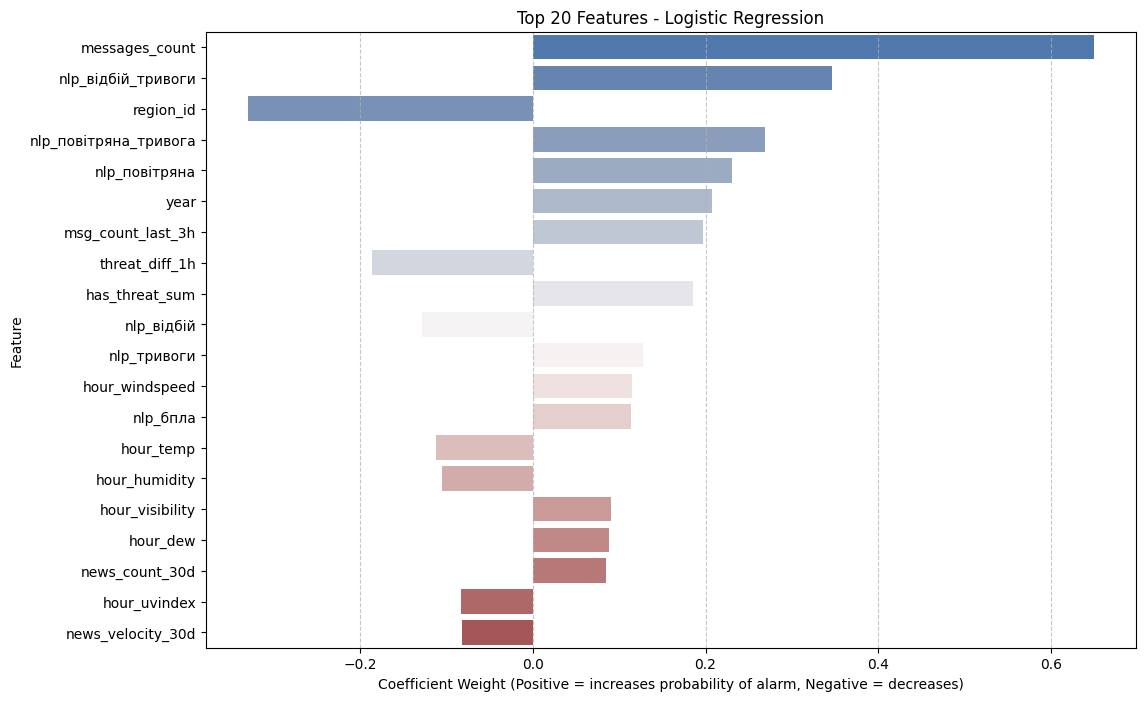

In [ ]:
feature_names = num_cols + cat_cols

coefs = best_pipeline.named_steps["model"].coef_[0]

# assembling into a dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": coefs
})

# calculating absolute weight to find the strongest features 
importance_df["Abs_Weight"] = importance_df["Weight"].abs()

# taking the top 20 most important features
top_20_features = importance_df.sort_values(by="Abs_Weight", ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_20_features, x="Weight", y="Feature", palette="vlag")
plt.title("Top 20 Features - Logistic Regression")
plt.xlabel("Coefficient Weight (Positive = increases probability of alarm, Negative = decreases)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()